# human like
## modern: human vs. plm

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl

In [3]:
human_sim = pd.read_csv('human_rating_data/human_model/human_33d_123r_cosine.csv',
                        encoding='UTF-8',index_col=0)
bert_sim = pd.read_csv('sim_bert_embedding/modern/q3.1_bert_embedding_data/MASK_embedding_output.csv',
                       encoding='gb18030',index_col=0)

<Axes: >

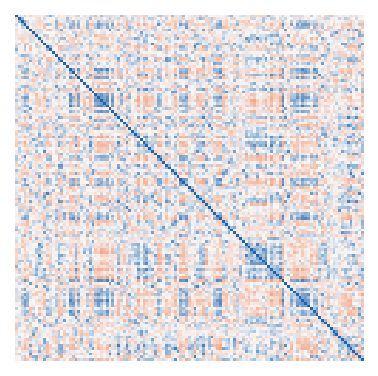

In [4]:
plt.figure(figsize=(3,3),dpi=150)
mycolor = ['#EF8A62','#F7F7F7','#2166AC']
cmaps = mpl.colors.LinearSegmentedColormap.from_list('mylist',mycolor,N=100)
sns.heatmap(human_sim,xticklabels='',yticklabels='',cmap = cmaps,cbar=False,vmin=-1, vmax=1)

<Axes: >

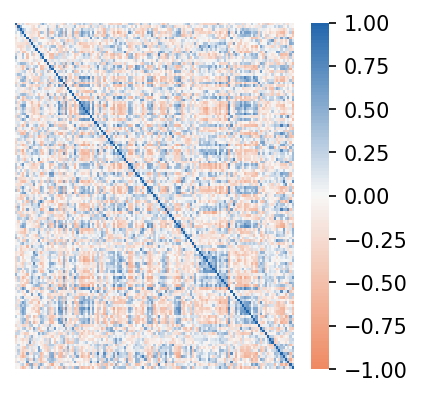

In [5]:
plt.figure(figsize=(3,3),dpi=150)
mycolor = ['#EF8A62','#F7F7F7','#2166AC']
cmaps = mpl.colors.LinearSegmentedColormap.from_list('mylist',mycolor,N=100)
sns.heatmap(human_sim,xticklabels='',yticklabels='',cmap = cmaps,vmin=-1, vmax=1)

<Axes: ylabel='Column1'>

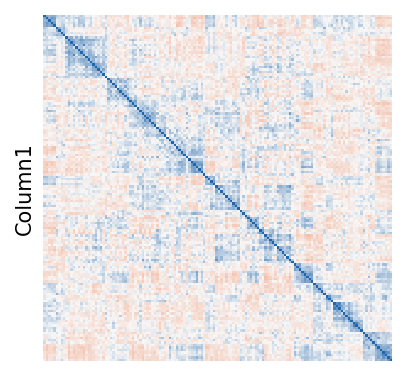

In [6]:
plt.figure(figsize=(3,3),dpi=150)
mycolor = ['#EF8A62','#F7F7F7','#2166AC']
cmaps = mpl.colors.LinearSegmentedColormap.from_list('mylist',mycolor,N=100)
sns.heatmap(bert_sim,xticklabels='',yticklabels='',cmap = cmaps,cbar=False,vmin=-1, vmax=1)

## ancient: 

In [9]:
bert_sim_ancient = pd.read_csv('sim_bert_embedding/ancient/q3.2_bert_embedding_data/MASK_embedding_output.csv',
                       encoding='UTF-8',index_col=0)

common_rows = bert_sim_ancient.index.intersection(human_sim.index)
common_cols = bert_sim_ancient.columns.intersection(human_sim.columns)
common = common_rows.intersection(common_cols)  
human_sim_ancient = human_sim.loc[common, common]
bert_sim_ancient = bert_sim_ancient.loc[common, common]

modern_rels = list(bert_sim.index)
ancient_in_modern_rels = [i for i in modern_rels if i in bert_sim_ancient.index]
len(ancient_in_modern_rels)

human_sim_ancient = human_sim_ancient.loc[ancient_in_modern_rels,ancient_in_modern_rels]
bert_sim_ancient = bert_sim_ancient.loc[ancient_in_modern_rels,ancient_in_modern_rels]

<Axes: >

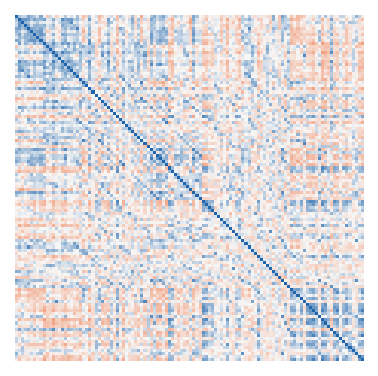

In [10]:
plt.figure(figsize=(3,3),dpi=150)
mycolor = ['#EF8A62','#F7F7F7','#2166AC']
cmaps = mpl.colors.LinearSegmentedColormap.from_list('mylist',mycolor,N=100)
sns.heatmap(human_sim_ancient,xticklabels='',yticklabels='',cmap = cmaps,cbar=False,vmin=-1, vmax=1)

<Axes: >

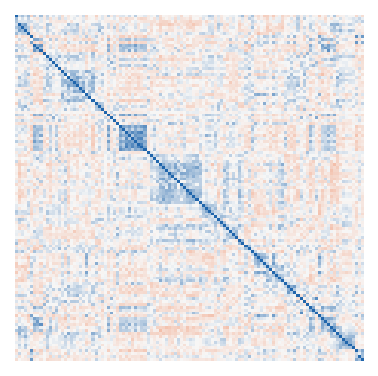

In [11]:
plt.figure(figsize=(3,3),dpi=150)
mycolor = ['#EF8A62','#F7F7F7','#2166AC']
cmaps = mpl.colors.LinearSegmentedColormap.from_list('mylist',mycolor,N=100)
sns.heatmap(bert_sim_ancient,xticklabels='',yticklabels='',cmap = cmaps,cbar=False,vmin=-1, vmax=1)

# reorder br clustering results

In [12]:
from sklearn.cluster import KMeans
random_state = 2023

In [13]:
human_df = pd.read_csv('human_rating_data/dim_rel_scaled_33d.csv',index_col=0,
                      encoding='gb18030')

model = KMeans(3, random_state=random_state)
model.fit(human_df)

cluster_labels = model.fit_predict(human_df)
human_df['cl_k3'] = cluster_labels

raw_results = human_df
for n in range(len(raw_results['cl_k3'].unique())):
    each_cluster = raw_results.index[raw_results['cl_k3']==n]
    print("\nCluster "+str(n+1)+" Relationship:{}".format(len(each_cluster)))
    print(*raw_results.index[raw_results['cl_k3']==n], sep = ", ")

Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "d:\Anaconda\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "d:\Anaconda\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "d:\Anaconda\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xcc in position 26: invalid continuation byte
d:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
'NoneType' object has no attribute 'splitlines'
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 262, 


Cluster 1 Relationship:34
从祖姑-从侄孙, 从祖母-从孙女, 伯母-侄女, 叔-嫂, 叔父-侄子, 堂姐夫-堂内弟, 外曾祖父-外曾孙, 外祖父-外孙女, 外祖父-外孙子, 姐夫-妻弟, 姑-嫂, 姑母-侄女, 姑表姐-姑表妹, 姨母-外甥, 姨母-外甥女, 姨表姐-姨表妹, 干妈-干女儿, 干爹-干儿子, 异父异母兄-异父异母妹, 异父异母姐-异父异母弟, 族伯叔-族侄, 族姐-族妹, 祖先-后代, 祖母-孙女, 祖父-孙女, 继外祖母-继外孙女, 继祖母-继孙女, 继祖父-继孙子, 舅母-外甥女, 舅表姐-舅表妹, 舅表姐-舅表弟, 表姐-表妹, 高祖母-玄孙, 高祖父-玄孙

Cluster 2 Relationship:40
三从兄-三从弟, 义母-义子, 义父-义女, 义父-义子, 伯母-侄子, 伯父-侄女婿, 伯父-侄子, 公公-儿媳, 养母-养子, 养父-养女, 再从兄-再从弟, 叔母-侄子, 同母异父兄-同母异父妹, 同母异父兄-同母异父弟, 同母异父姐-同母异父妹, 同母异父姐-同母异父弟, 同父异母兄-同父异母妹, 同父异母姐-同父异母妹, 堂兄-堂弟, 妹夫-妻姐, 姐夫-妹夫, 姑父-侄子, 姑表兄-姑表妹, 姑表兄-姑表弟, 姨表兄-姨表弟, 婆婆-儿媳, 岳母-女婿, 岳父-女婿, 异父异母姐-异父异母妹, 弟媳-伯, 继兄-继妹, 继外祖父-继外孙子, 继姐-继妹, 继姐-继弟, 继母-继女, 继母-继子, 继父-继女, 继父-继子, 继祖母-继孙子, 继祖父-继孙女

Cluster 3 Relationship:49
义母-义女, 亲家-亲家, 从祖父-从孙女, 从祖父-从孙子, 伯父-侄媳, 兄-妹, 兄-弟, 养母-养女, 养父-养子, 叔母-侄女, 叔父-侄女, 同父异母兄-同父异母弟, 堂伯-堂侄, 堂兄-堂妹, 堂姐-堂妹, 堂姐-堂弟, 堂祖母-堂侄孙, 堂祖父-堂侄孙, 外曾祖母-外曾孙, 外祖母-外孙女, 外祖母-外孙子, 夫-妻, 姐-妹, 姐-弟, 姑母-侄子, 姑表姐-姑表弟, 姨父-外甥, 姨表兄-姨表妹, 姨表姐-姨表弟, 曾祖母-曾孙女, 曾祖母-曾孙子, 曾祖父-曾孙女, 曾祖父-曾孙子, 母-女, 母-子, 父-女, 父-子, 祖母-孙子, 祖父-孙子, 继兄-继弟, 舅公

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
rels_order = list(human_df.sort_values('cl_k3').index)
human_sim_order = human_sim.loc[rels_order,rels_order]
bert_sim_order = bert_sim.loc[rels_order,rels_order]

<Axes: >

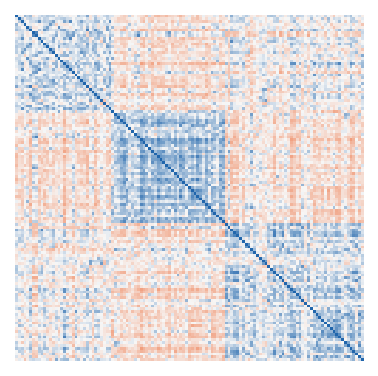

In [15]:
plt.figure(figsize=(3,3),dpi=150)
mycolor = ['#EF8A62','#F7F7F7','#2166AC']
cmaps = mpl.colors.LinearSegmentedColormap.from_list('mylist',mycolor,N=100)
sns.heatmap(human_sim_order,xticklabels='',yticklabels='',cmap = cmaps,cbar=False,vmin=-1, vmax=1)

<Axes: ylabel='Column1'>

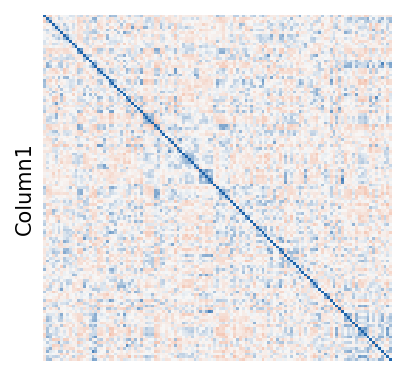

In [16]:
plt.figure(figsize=(3,3),dpi=150)
mycolor = ['#EF8A62','#F7F7F7','#2166AC']
cmaps = mpl.colors.LinearSegmentedColormap.from_list('mylist',mycolor,N=100)
sns.heatmap(bert_sim_order,xticklabels='',yticklabels='',cmap = cmaps,cbar=False,vmin=-1, vmax=1)

In [17]:
modern_bert_df = pd.read_csv('bert_embedding_data/modern/q3.1_bert_embedding_data/MASK_embedding_output.csv',
                       index_col=0,
                      encoding='gb18030')
modern_bert_df.index = modern_bert_df['word']
modern_bert_df = modern_bert_df.drop('word',axis=1)

model = KMeans(3, random_state=random_state)
model.fit(modern_bert_df)

cluster_labels = model.fit_predict(modern_bert_df)
modern_bert_df['cl_k3'] = cluster_labels

raw_results = modern_bert_df
for n in range(len(raw_results['cl_k3'].unique())):
    each_cluster = raw_results.index[raw_results['cl_k3']==n]
    print("\nCluster "+str(n+1)+" Relationship:{}".format(len(each_cluster)))
    print(*raw_results.index[raw_results['cl_k3']==n], sep = ", ")


Cluster 1 Relationship:42
伯父侄子之间, 伯父侄女之间, 伯母侄子之间, 伯母侄女之间, 叔父侄子之间, 叔父侄女之间, 叔母侄子之间, 叔母侄女之间, 姑父侄子之间, 表兄表妹之间, 表姐表弟之间, 姑表姐姑表弟之间, 姑表姐姑表妹之间, 舅表兄舅表妹之间, 舅表姐舅表弟之间, 舅表姐舅表妹之间, 姨表兄姨表弟之间, 姨表兄姨表妹之间, 姨表姐姨表弟之间, 兄妻弟妻之间, 姐夫妹夫之间, 从祖父从孙子之间, 从祖父从孙女之间, 从祖母从孙女之间, 从祖姑从侄孙之间, 三从兄三从弟之间, 继祖父继孙子之间, 继祖父继孙女之间, 继祖母继孙子之间, 继祖母继孙女之间, 继外祖父继外孙子之间, 继外祖父继外孙女之间, 继外祖母继外孙子之间, 继外祖母继外孙女之间, 同父异母兄同父异母妹之间, 同母异父姐同母异父妹之间, 同母异父兄同母异父妹之间, 同母异父姐同母异父弟之间, 异父异母兄异父异母弟之间, 异父异母姐异父异母妹之间, 异父异母兄异父异母妹之间, 异父异母姐异父异母弟之间

Cluster 2 Relationship:53
曾祖父曾孙子之间, 曾祖父曾孙女之间, 曾祖母曾孙女之间, 高祖父玄孙之间, 高祖母玄孙之间, 外曾祖父外曾孙之间, 外曾祖母外曾孙之间, 姑父侄女之间, 姑母侄子之间, 姑母侄女之间, 舅父外甥之间, 舅母外甥之间, 舅母外甥女之间, 姨父外甥之间, 姨父外甥女之间, 姨母外甥之间, 姨母外甥女之间, 堂兄堂弟之间, 堂兄堂妹之间, 堂姐堂弟之间, 堂姐堂妹之间, 表兄表弟之间, 表姐表妹之间, 姑表兄姑表弟之间, 姑表兄姑表妹之间, 舅表兄舅表弟之间, 姨表姐姨表妹之间, 舅父甥媳之间, 舅父甥女婿之间, 伯父侄媳之间, 伯父侄女婿之间, 姐夫妻弟之间, 妹夫妻兄之间, 妹夫妻姐之间, 叔嫂之间, 弟媳伯之间, 从祖母从孙子之间, 再从兄再从弟之间, 堂伯堂侄之间, 表叔表侄之间, 族伯叔族侄之间, 族兄族弟之间, 族姐族妹之间, 堂祖父堂侄孙之间, 堂祖母堂侄孙之间, 堂姐夫堂内弟之间, 表嫂表小叔之间, 姻伯叔姻侄之间, 舅公甥孙之间, 姨婆姨甥孙之间, 继兄继妹之间, 继姐继妹之间, 同父异母兄同父异母弟之间

Cluster 3 Relationship:47
夫妻之间, 父子之间, 父女之间, 母

d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
